In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

df = pd.read_csv("../f1_clean.csv")

FEATURES = ['grid', 'laps', 'points', 'fastestLapSpeed']
df = df.dropna(subset=FEATURES).reset_index(drop=True)
X = df[FEATURES].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dataset ready: {X_scaled.shape}")


Dataset ready: (5302, 4)


In [5]:
print("Linkage methods we will compare:")
for method, desc in [
    ('ward',     'minimise variance increase — best default'),
    ('complete', 'furthest pair — compact clusters'),
    ('average',  'mean of all pairs — balanced'),
    ('single',   'nearest pair — prone to chaining'),
]:
    print(f"  {method:<10} → {desc}")


Linkage methods we will compare:
  ward       → minimise variance increase — best default
  complete   → furthest pair — compact clusters
  average    → mean of all pairs — balanced
  single     → nearest pair — prone to chaining


In [6]:
Z = linkage(X_scaled, method='ward', metric='euclidean')

print(f"Linkage matrix shape: {Z.shape}")
print(f"Total merges performed: {len(Z)}  (always n_samples - 1 = {len(X_scaled)-1})")
print()
print("Last 5 merges (the highest-level ones — most important):")
print(f"{'Cluster A':>10} {'Cluster B':>10} {'Distance':>10} {'Size':>8}")
for row in Z[-5:]:
    print(f"{int(row[0]):>10} {int(row[1]):>10} {row[2]:>10.3f} {int(row[3]):>8}")


Linkage matrix shape: (5301, 4)
Total merges performed: 5301  (always n_samples - 1 = 5301)

Last 5 merges (the highest-level ones — most important):
 Cluster A  Cluster B   Distance     Size
     10589      10597     44.660     2408
     10594      10595     45.562     1560
     10592      10596     51.359     1334
     10598      10599     83.681     3968
     10600      10601    109.078     5302


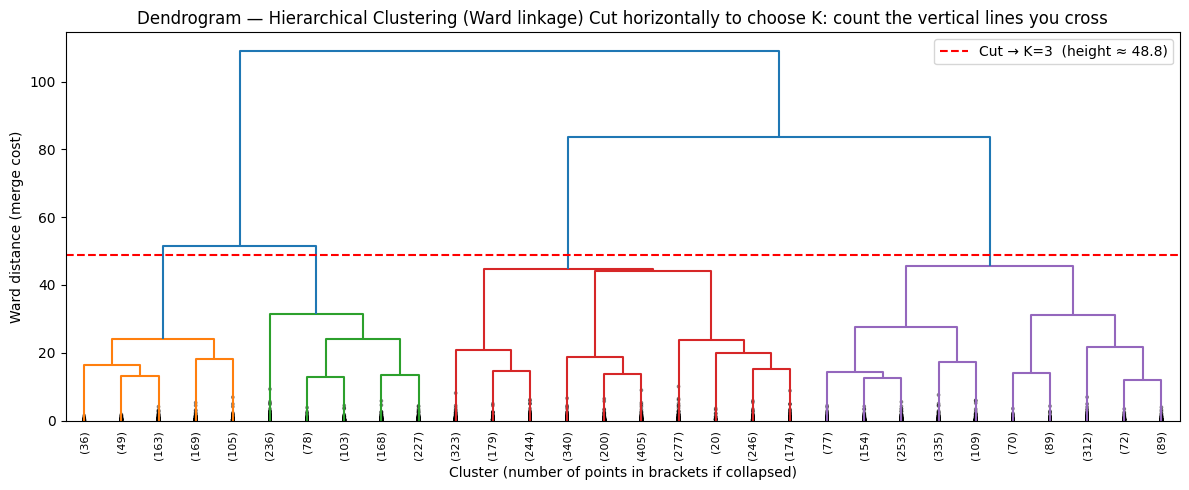

Saved: dendrogram.png

How to read: the red dashed line crosses 3 vertical lines → K=3 clusters.
Move the line up for fewer clusters, down for more.


In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

dendrogram(
    Z,
    ax=ax,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=8,
    show_contracted=True,
    color_threshold=Z[-3, 2]
)

ax.set_title("Dendrogram — Hierarchical Clustering (Ward linkage) Cut horizontally to choose K: count the vertical lines you cross")
ax.set_xlabel("Cluster (number of points in brackets if collapsed)")
ax.set_ylabel("Ward distance (merge cost)")

cut_height = Z[-3, 2] * 0.95
ax.axhline(y=cut_height, color='red', linestyle='--', linewidth=1.5,
           label=f'Cut → K=3  (height ≈ {cut_height:.1f})')
ax.legend()

plt.tight_layout()
plt.savefig("dendrogram.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: dendrogram.png")
print()
print("How to read: the red dashed line crosses 3 vertical lines → K=3 clusters.")
print("Move the line up for fewer clusters, down for more.")


In [8]:
linkage_methods = ['ward', 'complete', 'average', 'single']

print(f"{'Linkage':<12} {'Silhouette':>11} {'Cluster sizes'}")
print("-" * 55)

results = {}
for method in linkage_methods:
    agg = AgglomerativeClustering(
        n_clusters=3,
        linkage=method,
        metric='euclidean'
    )
    labels = agg.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    sizes = dict(pd.Series(labels).value_counts().sort_index())
    results[method] = {'labels': labels, 'silhouette': sil}

    print(f"{method:<12} {sil:>11.3f}   {sizes}")

best_method = max(results, key=lambda m: results[m]['silhouette'])
print(f"\nBest linkage: '{best_method}' (highest silhouette score)")


Linkage       Silhouette Cluster sizes
-------------------------------------------------------
ward               0.263   {0: np.int64(1334), 1: np.int64(1560), 2: np.int64(2408)}
complete           0.228   {0: np.int64(4759), 1: np.int64(20), 2: np.int64(523)}
average            0.377   {0: np.int64(5281), 1: np.int64(1), 2: np.int64(20)}
single             0.528   {0: np.int64(5300), 1: np.int64(1), 2: np.int64(1)}

Best linkage: 'single' (highest silhouette score)


In [9]:
agg_final = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward',
    metric='euclidean'
)

df['hc_label'] = agg_final.fit_predict(X_scaled)

print("=== Agglomerative Clustering (Ward, K=3) ===")
print(f"Silhouette score: {silhouette_score(X_scaled, df['hc_label']):.3f}")
print()
print("Cluster sizes:")
print(df['hc_label'].value_counts().sort_index())


=== Agglomerative Clustering (Ward, K=3) ===
Silhouette score: 0.263

Cluster sizes:
hc_label
0    1334
1    1560
2    2408
Name: count, dtype: int64


In [10]:
cluster_means = df.groupby('hc_label')['points'].mean()

label_map = {
    cluster_means.idxmax(): 'Winners',
    cluster_means.idxmin(): 'Backmarkers',
}
for c in [0, 1, 2]:
    if c not in label_map:
        label_map[c] = 'Midfield'

df['hc_name'] = df['hc_label'].map(label_map)

print("Cluster → name mapping:")
for k, v in label_map.items():
    print(f"  Cluster {k} → {v}  (avg points: {cluster_means[k]:.2f})")


Cluster → name mapping:
  Cluster 0 → Winners  (avg points: 16.22)
  Cluster 1 → Backmarkers  (avg points: 2.24)
  Cluster 2 → Midfield  (avg points: 2.33)


In [11]:
print("=== Hierarchical Clustering Profiles (mean values) ===")
profile = df.groupby('hc_name')[FEATURES + ['podium']].mean().round(2)
print(profile)
print()
print("=== Cluster sizes ===")
print(df['hc_name'].value_counts())


=== Hierarchical Clustering Profiles (mean values) ===
              grid   laps  points  fastestLapSpeed  podium
hc_name                                                   
Backmarkers  13.20  68.48    2.24           193.29    0.01
Midfield     13.09  53.28    2.33           210.14    0.02
Winners       3.54  59.77   16.22           209.11    0.64

=== Cluster sizes ===
hc_name
Midfield       2408
Backmarkers    1560
Winners        1334
Name: count, dtype: int64


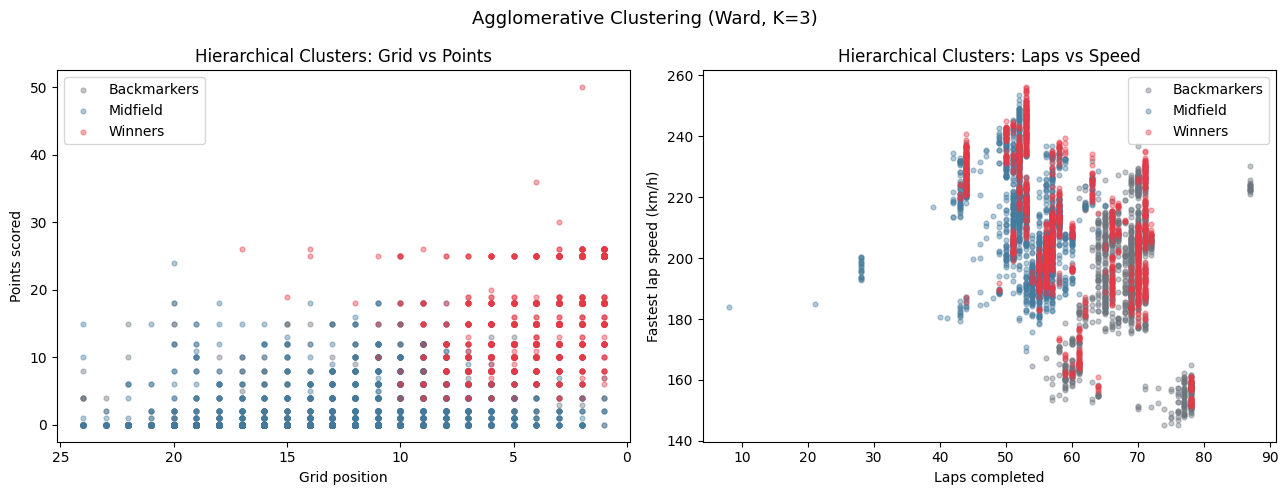

Saved: hierarchical_clusters.png


In [12]:
colors = {'Winners': '#e63946', 'Midfield': '#457b9d', 'Backmarkers': '#6c757d'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for name, group in df.groupby('hc_name'):
    ax.scatter(group['grid'], group['points'],
               color=colors[name], label=name, alpha=0.4, s=12)
ax.set_xlabel("Grid position")
ax.set_ylabel("Points scored")
ax.set_title("Hierarchical Clusters: Grid vs Points")
ax.invert_xaxis()
ax.legend()
# Plot 2: Laps vs fastestLapSpeed

ax2 = axes[1]
for name, group in df.groupby('hc_name'):
    ax2.scatter(group['laps'], group['fastestLapSpeed'],
                color=colors[name], label=name, alpha=0.4, s=12)
ax2.set_xlabel("Laps completed")
ax2.set_ylabel("Fastest lap speed (km/h)")
ax2.set_title("Hierarchical Clusters: Laps vs Speed")
ax2.legend()

plt.suptitle("Agglomerative Clustering (Ward, K=3)", fontsize=13)
plt.tight_layout()
plt.savefig("hierarchical_clusters.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: hierarchical_clusters.png")


In [13]:
from sklearn.metrics import adjusted_rand_score

from sklearn.cluster import KMeans, DBSCAN as DB

km = KMeans(n_clusters=3, init='k-means++', n_init=10,
            random_state=42).fit(X_scaled)

db = DB(eps=1.5, min_samples=8).fit(X_scaled)

labels_km = km.labels_
labels_hc = df['hc_label'].values
labels_db = db.labels_

mask = labels_db != -1
n_noise = (labels_db == -1).sum()

print("=== Agreement between clustering methods ===")
print(f"(DBSCAN excluded {n_noise} noise points from comparison)")
print()
print(f"K-Means++ vs Hierarchical : {adjusted_rand_score(labels_km, labels_hc):.3f}")
print(f"K-Means++ vs DBSCAN       : {adjusted_rand_score(labels_km[mask], labels_db[mask]):.3f}")
print(f"Hierarchical vs DBSCAN    : {adjusted_rand_score(labels_hc[mask], labels_db[mask]):.3f}")
print()
print("Interpretation:")
print("  > 0.8 → methods agree strongly — structure is real")
print("  0.5–0.8 → partial agreement — methods see different things")
print("  < 0.5 → methods disagree — data may not have clear clusters")

=== Agreement between clustering methods ===
(DBSCAN excluded 4 noise points from comparison)

K-Means++ vs Hierarchical : 0.749
K-Means++ vs DBSCAN       : -0.000
Hierarchical vs DBSCAN    : -0.001

Interpretation:
  > 0.8 → methods agree strongly — structure is real
  0.5–0.8 → partial agreement — methods see different things
  < 0.5 → methods disagree — data may not have clear clusters
